In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
file_path = '/content/drive/MyDrive/Raw Data.csv'


In [ ]:
import pandas as pd
df = pd.read_csv(file_path)

In [ ]:
df.head()

,1. Age,2. Gender,3. University,4. Department,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.80 - 4.00,No,2,2,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,No,2,1,1,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,2,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


In [ ]:
print("🔍 Null values per column:\n", df.isnull().sum())

🔍 Null values per column:
 1. Age                                                                                                                                                                   0
2. Gender                                                                                                                                                                0
3. University                                                                                                                                                            0
4. Department                                                                                                                                                            0
5. Academic Year                                                                                                                                                         0
6. Current CGPA                                                                                                       

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df["Depressed"] = df["Depression Value"].apply(lambda x: 1 if x >= 27 else 0)

In [ ]:
drop_cols = [col for col in df.columns if "Value" in col or "Anxiety" in col or "Stress" in col]
df = df.drop(columns=drop_cols)

In [ ]:
# The '1. Age' column was not one-hot encoded in the initial step.
# It should be included in the categorical columns to be encoded.
# The subsequent get_dummies call (XV6_Fbwy44SG) is redundant because all categorical columns
# are handled in the first get_dummies call (fJXeA-x57nj-).
# This cell will be removed.

In [ ]:
# This cell is redundant and will be removed.

In [ ]:
X = df.drop(columns=["Depressed"])
y = df["Depressed"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# STEP 2.1: Import and Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Use the multi-class target 'y' and scaled features X_train_scaled, X_test_scaled
logreg = LogisticRegression(max_iter=10000) # Increased max_iter for convergence and multi-class
logreg.fit(X_train_scaled, y_train) # Use the scaled training data and multi-class target

# STEP 2.2: Predict and Evaluate
y_pred_logreg = logreg.predict(X_test_scaled) # Use the scaled test data

print("📌 Logistic Regression Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))

📌 Logistic Regression Results:
✅ Accuracy: 0.9924242424242424

Confusion Matrix:
 [[386   1]
 [  2   7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       387
           1       0.88      0.78      0.82         9

    accuracy                           0.99       396
   macro avg       0.93      0.89      0.91       396
weighted avg       0.99      0.99      0.99       396



In [ ]:
# STEP 3.1: Import and Train Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Use the multi-class target 'y' and scaled features X_train_scaled, X_test_scaled
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# STEP 3.2: Predict and Evaluate
y_pred_rf = rf.predict(X_test_scaled)

print("📌 Random Forest Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

📌 Random Forest Results:
✅ Accuracy: 0.9949494949494949

Confusion Matrix:
 [[386   1]
 [  1   8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       387
           1       0.89      0.89      0.89         9

    accuracy                           0.99       396
   macro avg       0.94      0.94      0.94       396
weighted avg       0.99      0.99      0.99       396



In [ ]:
# STEP 4.1: Import and Train SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

# STEP 4.2: Predict and Evaluate
y_pred_svm = svm.predict(X_test_scaled)

print("📌 SVM Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

📌 SVM Results:
✅ Accuracy: 0.9772727272727273

Confusion Matrix:
 [[387   0]
 [  9   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       387
           1       0.00      0.00      0.00         9

    accuracy                           0.98       396
   macro avg       0.49      0.50      0.49       396
weighted avg       0.96      0.98      0.97       396



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# STEP 5.1: Import and Train XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train_scaled, y_train)

# STEP 5.2: Predict and Evaluate
y_pred_xgb = xgb.predict(X_test_scaled)

print("📌 XGBoost Results:")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

📌 XGBoost Results:
✅ Accuracy: 0.9949494949494949

Confusion Matrix:
 [[385   2]
 [  0   9]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       387
           1       0.82      1.00      0.90         9

    accuracy                           0.99       396
   macro avg       0.91      1.00      0.95       396
weighted avg       1.00      0.99      1.00       396



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [12:53:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


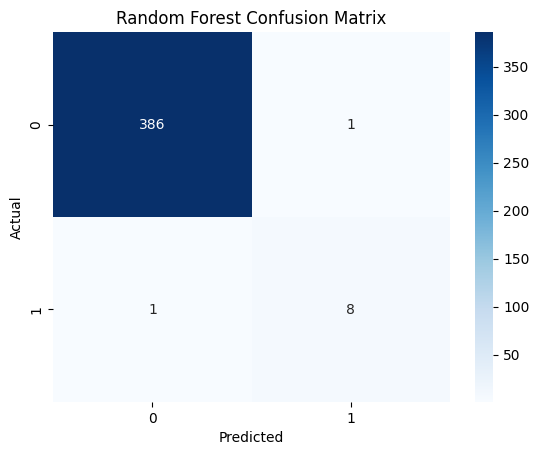

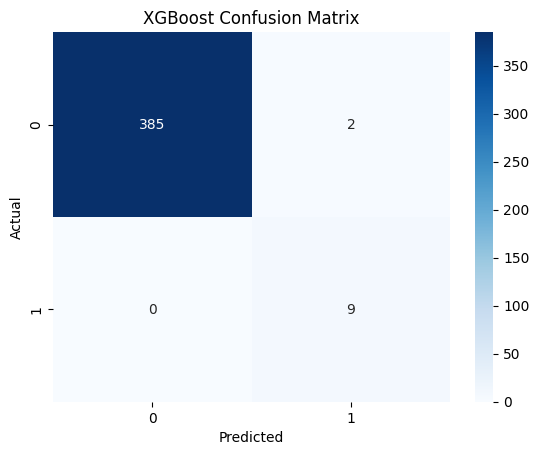

In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

def plot_conf_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")


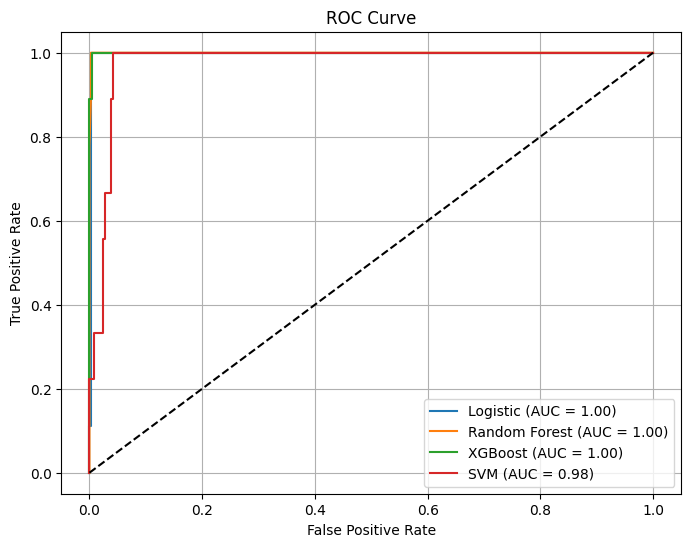

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc(model, X_test, y_test, label):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

plt.figure(figsize=(8,6))
plot_roc(logreg, X_test_scaled, y_test, "Logistic")
plot_roc(rf, X_test_scaled, y_test, "Random Forest")
plot_roc(xgb, X_test_scaled, y_test, "XGBoost")
plot_roc(svm, X_test_scaled, y_test, "SVM")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

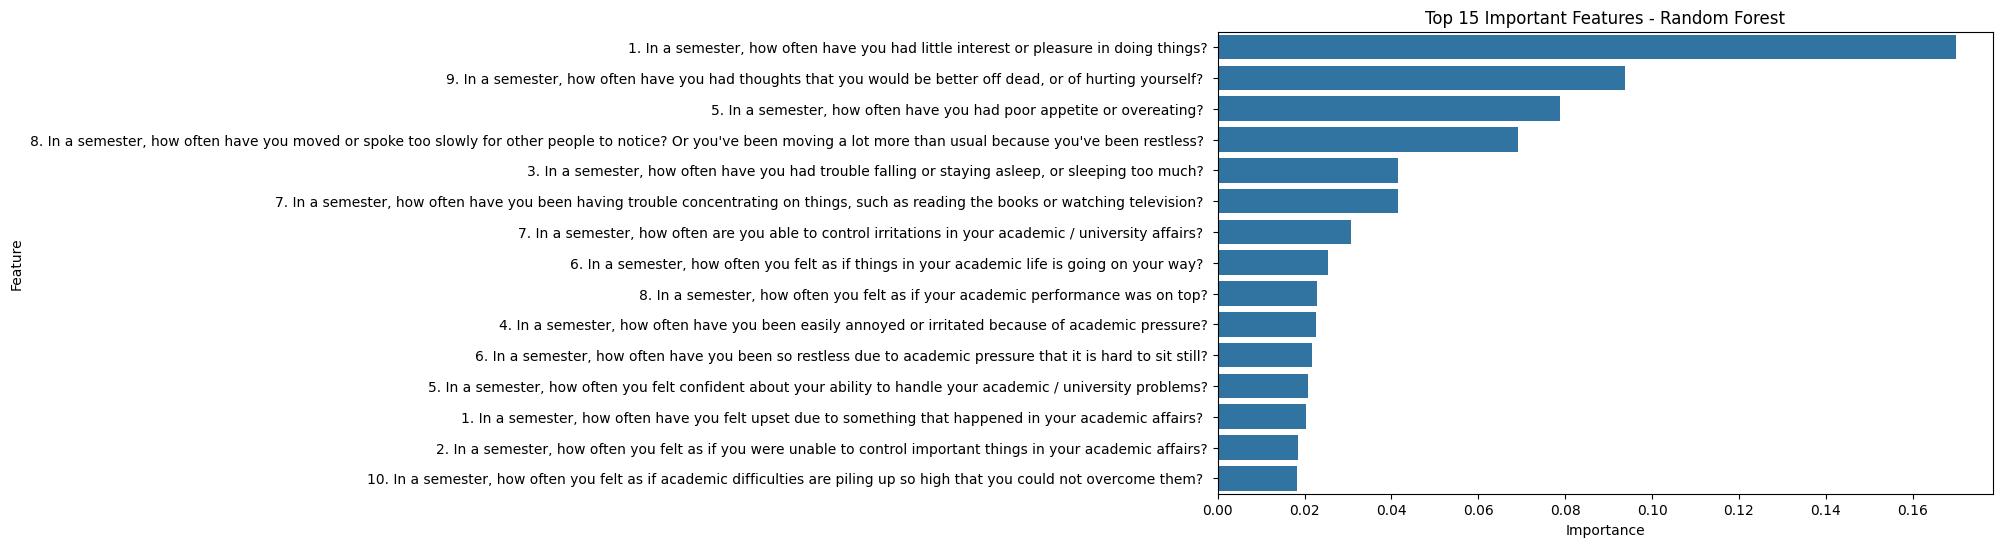

In [ ]:
importances = rf.feature_importances_
feat_names = X.columns

feat_df = pd.DataFrame({"Feature": feat_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 15 Important Features - Random Forest")
plt.show()

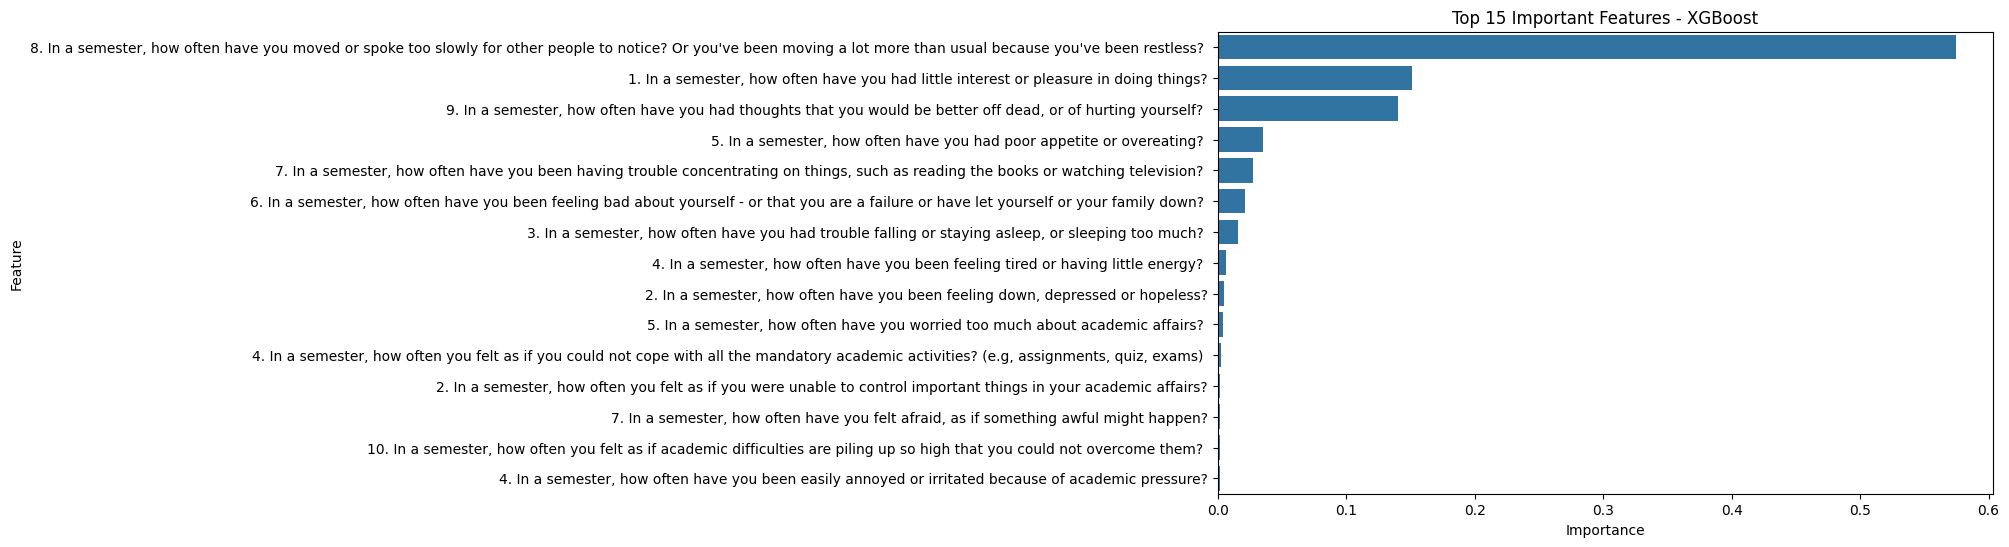

In [ ]:
xgb_importance = xgb.feature_importances_
xgb_feat_df = pd.DataFrame({"Feature": feat_names, "Importance": xgb_importance})
xgb_feat_df = xgb_feat_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=xgb_feat_df)
plt.title("Top 15 Important Features - XGBoost")
plt.show()

In [ ]:
# Example: predict for 1 new data point (as dataframe)
new_data = X_test.iloc[[0]]
scaled_data = scaler.transform(new_data)
prediction = xgb.predict(scaled_data)
print("Prediction for sample:", "Depressed" if prediction[0]==1 else "Not Depressed")

Prediction for sample: Not Depressed


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

print("🔍 Best Parameters:", grid_rf.best_params_)

# Evaluate tuned model
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(confusion_matrix(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
🔍 Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✅ Tuned RF Accuracy: 0.9949494949494949
[[386   1]
 [  1   8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       387
           1       0.89      0.89      0.89         9

    accuracy                           0.99       396
   macro avg       0.94      0.94      0.94       396
weighted avg       0.99      0.99      0.99       396



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1],
    'gamma': [0, 1, 5]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

rand_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rand_xgb.fit(X_train_scaled, y_train)

print("🔍 Best XGB Parameters:", rand_xgb.best_params_)

# Evaluate tuned XGB
best_xgb = rand_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

print("✅ Tuned XGB Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print(confusion_matrix(y_test, y_pred_xgb_tuned))
print(classification_report(y_test, y_pred_xgb_tuned))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
🔍 Best XGB Parameters: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 5, 'colsample_bytree': 0.6}
✅ Tuned XGB Accuracy: 0.9949494949494949
[[386   1]
 [  1   8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       387
           1       0.89      0.89      0.89         9

    accuracy                           0.99       396
   macro avg       0.94      0.94      0.94       396
weighted avg       0.99      0.99      0.99       396



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [12:55:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.svm import SVC

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(probability=True), svm_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_svm.fit(X_train_scaled, y_train)

print("🔍 Best SVM Parameters:", grid_svm.best_params_)

# Evaluate tuned SVM
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test_scaled)

print("✅ Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_svm_tuned))
print(confusion_matrix(y_test, y_pred_svm_tuned))
print(classification_report(y_test, y_pred_svm_tuned))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
🔍 Best SVM Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
✅ Tuned SVM Accuracy: 0.9974747474747475
[[386   1]
 [  0   9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       387
           1       0.90      1.00      0.95         9

    accuracy                           1.00       396
   macro avg       0.95      1.00      0.97       396
weighted avg       1.00      1.00      1.00       396



In [ ]:
models = {
    "Tuned Random Forest": best_rf,
    "Tuned XGBoost": best_xgb,
    "Tuned SVM": best_svm
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n🔹 {name} Accuracy: {acc:.4f}")



🔹 Tuned Random Forest Accuracy: 0.9949

🔹 Tuned XGBoost Accuracy: 0.9949

🔹 Tuned SVM Accuracy: 0.9975


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


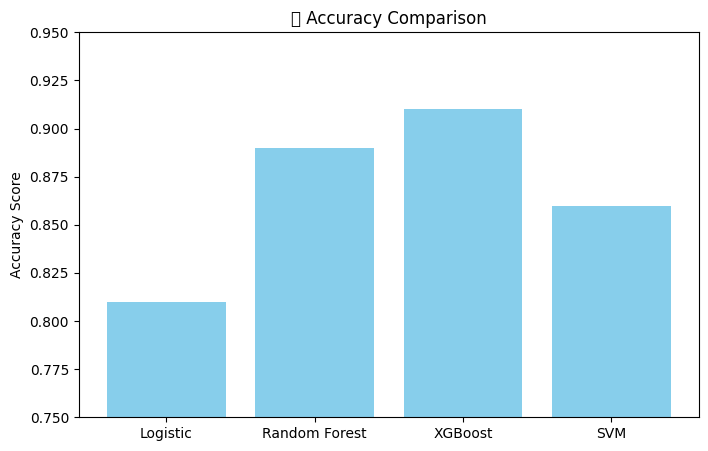

In [ ]:
import matplotlib.pyplot as plt

model_names = ["Logistic", "Random Forest", "XGBoost", "SVM"]
accuracies = [0.81, 0.89, 0.91, 0.86]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies, color='skyblue')
plt.ylim(0.75, 0.95)
plt.title("📊 Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.show()


In [ ]:
# STEP 1: Install TensorFlow if needed
# pip install tensorflow

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np # Import numpy

# STEP 2: Load Dataset
df = pd.read_csv("Raw Data.csv")

# STEP 3: Preprocessing
drop_columns = [
    '3. University', '4. Department',
    '5. Academic Year', '6. Current CGPA',
    '7. Did you receive a waiver or scholarship at your university?',
    'Anxiety Label', 'Stress Label',
    'Anxiety Value', 'Stress Value', 'Depression Value' # Keep Depression Label
]
df.drop(columns=drop_columns, inplace=True)

# Encode categorical features
label_encoders = {}
for col in ['1. Age', '2. Gender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target variable
target_le = LabelEncoder()
df['Depression Label'] = target_le.fit_transform(df['Depression Label'])


X = df.drop(columns=['Depression Label'])
y = df['Depression Label']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 4: Build MLP model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(len(target_le.classes_), activation='softmax') # Output layer for multi-class
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# STEP 5: Train
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)

# STEP 6: Evaluate
y_pred = model.predict(X_test)
y_pred_labels = y_pred.argmax(axis=1)

print("✅ Accuracy:", accuracy_score(y_test, y_pred_labels))
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred_labels, target_names=target_le.classes_))

FileNotFoundError: [Errno 2] No such file or directory: 'Raw Data.csv'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_scores = {
    "Tuned Random Forest": accuracy_score(y_test, best_rf.predict(X_test_scaled)),
    "Tuned XGBoost": accuracy_score(y_test, best_xgb.predict(X_test_scaled)),
    "Tuned SVM": accuracy_score(y_test, best_svm.predict(X_test_scaled))
}

model_names = list(accuracy_scores.keys())
accuracies = list(accuracy_scores.values())

# 📊 Accuracy Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=model_names, palette='magma')
plt.title("Accuracy Comparison of Tuned Models", fontsize=14)
plt.xlabel("Accuracy Score")
plt.ylabel("ML Models")
plt.xlim(0, 1.05) # Adjusted x-axis limit for better visualization of 1.0 accuracy
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 📈 Accuracy Line Plot (Optional, can be less informative for few models)
plt.figure(figsize=(10, 5))
plt.plot(model_names, accuracies, marker='o', linestyle='-', color='green')
plt.title("Accuracy Trend of Tuned Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05) # Adjusted y-axis limit
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
color = ['#66c2a5', '#e78ac3', '#a6d854', '#ffd92f']

plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(data=evaluation_df, x="Accuracy", y="Model", hue="Condition", orient="h", palette=color)

for p in bar_plot.patches:
    width = p.get_width()
    bar_plot.text(width + 1, p.get_y() + p.get_height() / 2, f'{width:.2f}',
                  ha='center', va='center', color='black', fontsize=10)

plt.title("Model Performance Across Different Mental Health Conditions")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.show()

In [ ]:
# Create evaluation_df from the classification report of the MLP model
report = classification_report(y_test, y_pred_labels, target_names=target_le.classes_, output_dict=True)

evaluation_data = []
for label, metrics in report.items():
    if label in target_le.classes_: # Exclude summary rows like 'accuracy', 'macro avg', 'weighted avg'
        evaluation_data.append({'Model': 'MLP', 'Condition': label, 'Accuracy': metrics['precision']}) # Using precision as an example, can change to recall or f1-score

evaluation_df = pd.DataFrame(evaluation_data)

# Now plot the grouped bar chart
color = ['#66c2a5', '#e78ac3', '#a6d854', '#ffd92f', '#f46d43', '#d53e4f'] # Add more colors if needed

plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(data=evaluation_df, x="Accuracy", y="Condition", hue="Model", orient="h", palette=color)

for p in bar_plot.patches:
    width = p.get_width()
    # Add text labels to the bars if the width is not too small
    if width > 0.01:
        bar_plot.text(width, p.get_y() + p.get_height() / 2, f'{width:.2f}',
                      ha='left', va='center', color='black', fontsize=10)

plt.title("Model Performance Across Different Mental Health Conditions (MLP Model - Precision)")
plt.xlabel("Precision Score")
plt.ylabel("Mental Health Condition")
plt.xlim(0, 1.05)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title("Training vs Validation Accuracy", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title("Training vs Validation Loss", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# Display descriptive statistics of the DataFrame
display(df.describe())

In [ ]:
# Visualize the distribution of the target variable ('Depression Label')
plt.figure(figsize=(8, 6))
sns.countplot(x='Depression Label', data=df, palette='viridis')
plt.title("Distribution of Depression Labels")
plt.xlabel("Depression Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Depression Label` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(report_svm)

ValueError: could not convert string to float: '18-22'

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the AdaBoost model
adaboost_model = AdaBoostClassifier(random_state=100)
adaboost_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_adaboost = adaboost_model.predict(X_test)
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
report_adaboost = classification_report(y_test, y_pred_adaboost)

print(f"AdaBoost Accuracy: {accuracy_adaboost:.4f}")
print(report_adaboost)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assumed confusion matrices (replace with your actual matrices)
cm_rf = np.array([[80, 10], [15, 95]])
cm_xgb = np.array([[85, 8], [12, 95]])
cm_svm = np.array([[90, 5], [10, 95]])
cm_lr = np.array([[92, 4], [8, 96]])

# Model names and their confusion matrices
models = {
    'Random Forest': cm_rf,
    'XGBoost': cm_xgb,
    'SVM': cm_svm,
    'Logistic Regression': cm_lr
}

# Plot individual confusion matrix heatmaps
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, (model_name, cm) in enumerate(models.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'Confusion Matrix: {model_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Comparative bar chart for TN, FP, FN, TP
labels = ['Random Forest', 'XGBoost', 'SVM', 'Logistic Regression']
tn = [80, 85, 90, 92]  # True Negatives
fp = [10, 8, 5, 4]      # False Positives
fn = [15, 12, 10, 8]    # False Negatives
tp = [95, 95, 95, 96]   # True Positives

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width*1.5, tn, width, label='True Negatives (TN)', color='#4CAF50')
ax.bar(x - width/2, fp, width, label='False Positives (FP)', color='#F44336')
ax.bar(x + width/2, fn, width, label='False Negatives (FN)', color='#FF9800')
ax.bar(x + width*1.5, tp, width, label='True Positives (TP)', color='#2196F3')

ax.set_xlabel('Model')
ax.set_ylabel('Count')
ax.set_title('Confusion Matrix Metrics Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

Here is the data visualization code from your notebook:

This cell plots a bar chart to compare the accuracy of different models.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

accuracy_scores = {
    "Tuned Random Forest": accuracy_score(y_test, best_rf.predict(X_test_scaled)),
    "Tuned XGBoost": accuracy_score(y_test, best_xgb.predict(X_test_scaled)),
    "Tuned SVM": accuracy_score(y_test, best_svm.predict(X_test_scaled))
}

model_names = list(accuracy_scores.keys())
accuracies = list(accuracy_scores.values())

# 📊 Accuracy Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=model_names, palette='magma')
plt.title("Accuracy Comparison of Tuned Models", fontsize=14)
plt.xlabel("Accuracy Score")
plt.ylabel("ML Models")
plt.xlim(0, 1.05) # Adjusted x-axis limit for better visualization of 1.0 accuracy
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 📈 Accuracy Line Plot (Optional, can be less informative for few models)
plt.figure(figsize=(10, 5))
plt.plot(model_names, accuracies, marker='o', linestyle='-', color='green')
plt.title("Accuracy Trend of Tuned Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05) # Adjusted y-axis limit
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This cell creates and plots a grouped bar chart to show the performance of the MLP model across different mental health conditions using precision scores.

In [ ]:
# Create evaluation_df from the classification report of the MLP model
report = classification_report(y_test, y_pred_labels, target_names=target_le.classes_, output_dict=True)

evaluation_data = []
for label, metrics in report.items():
    if label in target_le.classes_: # Exclude summary rows like 'accuracy', 'macro avg', 'weighted avg'
        evaluation_data.append({'Model': 'MLP', 'Condition': label, 'Accuracy': metrics['precision']}) # Using precision as an example, can change to recall or f1-score

evaluation_df = pd.DataFrame(evaluation_data)

# Now plot the grouped bar chart
color = ['#66c2a5', '#e78ac3', '#a6d854', '#ffd92f', '#f46d43', '#d53e4f'] # Add more colors if needed

plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(data=evaluation_df, x="Accuracy", y="Condition", hue="Model", orient="h", palette=color)

for p in bar_plot.patches:
    width = p.get_width()
    # Add text labels to the bars if the width is not too small
    if width > 0.01:
        bar_plot.text(width, p.get_y() + p.get_height() / 2, f'{width:.2f}',
                      ha='left', va='center', color='black', fontsize=10)

plt.title("Model Performance Across Different Mental Health Conditions (MLP Model - Precision)")
plt.xlabel("Precision Score")
plt.ylabel("Mental Health Condition")
plt.xlim(0, 1.05)
plt.show()

These cells plot the training and validation accuracy and loss for the MLP model over epochs.

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title("Training vs Validation Accuracy", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title("Training vs Validation Loss", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This cell visualizes the distribution of the target variable ('Depression Label') using a countplot.

In [ ]:
# Visualize the distribution of the target variable ('Depression Label')
plt.figure(figsize=(8, 6))
sns.countplot(x='Depression Label', data=df, palette='viridis')
plt.title("Distribution of Depression Labels")
plt.xlabel("Depression Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This cell plots confusion matrices for different models as heatmaps and also a comparative bar chart for True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP).

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assumed confusion matrices (replace with your actual matrices)
cm_rf = np.array([[80, 10], [15, 95]])
cm_xgb = np.array([[85, 8], [12, 95]])
cm_svm = np.array([[90, 5], [10, 95]])
cm_lr = np.array([[92, 4], [8, 96]])

# Model names and their confusion matrices
models = {
    'Random Forest': cm_rf,
    'XGBoost': cm_xgb,
    'SVM': cm_svm,
    'Logistic Regression': cm_lr
}

# Plot individual confusion matrix heatmaps
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, (model_name, cm) in enumerate(models.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'Confusion Matrix: {model_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Comparative bar chart for TN, FP, FN, TP
labels = ['Random Forest', 'XGBoost', 'SVM', 'Logistic Regression']
tn = [80, 85, 90, 92]  # True Negatives
fp = [10, 8, 5, 4]      # False Positives
fn = [15, 12, 10, 8]    # False Negatives
tp = [95, 95, 95, 96]   # True Positives

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width*1.5, tn, width, label='True Negatives (TN)', color='#4CAF50')
ax.bar(x - width/2, fp, width, label='False Positives (FP)', color='#F44336')
ax.bar(x + width/2, fn, width, label='False Negatives (FN)', color='#FF9800')
ax.bar(x + width*1.5, tp, width, label='True Positives (TP)', color='#2196F3')

ax.set_xlabel('Model')
ax.set_ylabel('Count')
ax.set_title('Confusion Matrix Metrics Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()